In [1]:
import lightkurve
import matplotlib.pyplot as plot
import numpy
import triceratops.triceratops as tr
import json

%matplotlib inline
# plot.style.use('seaborn-v0_8')

In [2]:
parent_folder = 'CTOI Creation'

In [3]:
data_paths = []

with open(f'{parent_folder}/queue_data_paths.txt', 'r+') as file:
    data_paths.extend([file_name.strip() for file_name in file.readlines()])
    file.seek(0)

data_paths

['CTOI Creation/Candidates/TIC 259171171/save_data/TIC 259171171 b @ 2025-June-28 12:58:03 PM.json']

In [4]:
data_path = data_paths[0]
data_path

'CTOI Creation/Candidates/TIC 259171171/save_data/TIC 259171171 b @ 2025-June-28 12:58:03 PM.json'

In [5]:
with open(data_path, 'r') as file:
    data = json.load(file)

data

{'exoplanet_num': 1,
 'flux_unc': 0.009526713356416862,
 'host_star': {'name': 'TIC 259171171'},
 'id_num': 259171171,
 'letter': 'b',
 'name': 'TIC 259171171 b',
 'parameters': {},
 'period': 2.9773925251720477,
 'period_fwhm': 0.025094541936334647,
 'period_unc': 0.012547270968167323,
 'signal_to_noise_ratio': 11.5345405177619,
 'transit_depth': 0.027789571312280215,
 'transit_depth_unc': 0.009831057036288147,
 'transit_duration': 2.429552300540391,
 'transit_duration_unc': 0.21063277698831198,
 'transit_time': 3287.2275099054414,
 'transit_time_unc': 0.008776365707846333,
 'triceratops': {'period': 2.9773925251720477,
  'transit_depth': 0.027789571312280215,
  'transit_duration': 2.429552300540391,
  'transit_time': 3287.2275099054414}}

In [6]:
star_id = data['id_num']
star_id

259171171

In [7]:
triceratops = data['triceratops']
triceratops

{'period': 2.9773925251720477,
 'transit_depth': 0.027789571312280215,
 'transit_duration': 2.429552300540391,
 'transit_time': 3287.2275099054414}

In [8]:
search_result = lightkurve.search_lightcurve(f'TIC {star_id}', mission = 'TESS')[:20]
search_result

#,mission,year,author,exptime,target_name,distance
,,,,s,,arcsec
0,TESS Sector 73,2023,SPOC,120,259171171,0.0
1,TESS Sector 82,2024,SPOC,120,259171171,0.0
2,TESS Sector 75,2024,SPOC,120,259171171,0.0
3,TESS Sector 76,2024,SPOC,120,259171171,0.0
4,TESS Sector 77,2024,SPOC,120,259171171,0.0
5,TESS Sector 83,2024,SPOC,120,259171171,0.0
6,TESS Sector 79,2024,SPOC,120,259171171,0.0
7,TESS Sector 80,2024,SPOC,120,259171171,0.0
8,TESS Sector 81,2024,SPOC,120,259171171,0.0


In [16]:
lc = search_result[11].download_all().stitch()
lc

time,flux,flux_err,timecorr,cadenceno,centroid_col,centroid_row,sap_flux,sap_flux_err,sap_bkg,sap_bkg_err,pdcsap_flux,pdcsap_flux_err,quality,psf_centr1,psf_centr1_err,psf_centr2,psf_centr2_err,mom_centr1,mom_centr1_err,mom_centr2,mom_centr2_err,pos_corr1,pos_corr2
,,,d,,pix,pix,electron / s,electron / s,electron / s,electron / s,electron / s,electron / s,,pix,pix,pix,pix,pix,pix,pix,pix,pix,pix
Time,float32,float32,float32,int32,float64,float64,float32,float32,float32,float32,float32,float32,int32,float64,float32,float64,float32,float64,float32,float64,float32,float32,float32
3285.8001479288737,1.0135379e+00,1.0706509e-02,6.5682043e-04,889203,1028.67809,953.65594,3.7279944e+02,2.7748957e+00,3.9819269e+02,1.1845251e+00,3.7498465e+02,3.9611509e+00,0,———,———,———,———,1028.67809,3.3389870e-03,953.65594,4.8313518e-03,8.3643598e-03,-7.5591877e-02
3285.802462713353,1.0042418e+00,1.0711523e-02,6.5679115e-04,889204,1028.67179,953.66654,3.7036746e+02,2.7761948e+00,3.9839349e+02,1.1832671e+00,3.7154532e+02,3.9630058e+00,0,———,———,———,———,1028.67179,3.3684010e-03,953.66654,4.8621772e-03,5.7151364e-03,-7.7733062e-02
3285.8047774978318,9.9596852e-01,1.0678366e-02,6.5676187e-04,889205,1028.67591,953.66430,3.6806442e+02,2.7676015e+00,3.9653522e+02,1.1808256e+00,3.6848441e+02,3.9507387e+00,0,———,———,———,———,1028.67591,3.3733484e-03,953.66430,4.8775775e-03,7.4341930e-03,-7.5115636e-02
3285.8070922822526,1.0171468e+00,1.0708685e-02,6.5673253e-04,889206,1028.66734,953.65626,3.7384436e+02,2.7754598e+00,3.9897046e+02,1.1816845e+00,3.7631989e+02,3.9619560e+00,0,———,———,———,———,1028.66734,3.3353525e-03,953.65626,4.8116427e-03,4.6785916e-03,-8.0460213e-02
3285.8094070666157,1.0065511e+00,1.0701444e-02,6.5670314e-04,889207,1028.67322,953.66379,3.7120795e+02,2.7735827e+00,3.9761981e+02,1.1823274e+00,3.7239972e+02,3.9592769e+00,0,———,———,———,———,1028.67322,3.3523154e-03,953.66379,4.8376238e-03,8.2732411e-03,-7.5781293e-02
3285.811721851037,9.8742735e-01,1.0667560e-02,6.5667380e-04,889208,1028.67423,953.65167,3.6629440e+02,2.7648008e+00,3.9761276e+02,1.1824421e+00,3.6532437e+02,3.9467404e+00,0,———,———,———,———,1028.67423,3.3853264e-03,953.65167,4.8912992e-03,6.3092075e-03,-7.9585075e-02
3285.8140366353996,9.9941462e-01,1.0709888e-02,6.5664441e-04,889209,1028.67249,953.66497,3.6943280e+02,2.7757714e+00,3.9596118e+02,1.1797035e+00,3.6975937e+02,3.9624012e+00,0,———,———,———,———,1028.67249,3.3672124e-03,953.66497,4.8835683e-03,8.0305301e-03,-7.5602472e-02
3285.8163514197618,1.0046858e+00,1.0686871e-02,6.5661501e-04,889210,1028.67680,953.66187,3.7068353e+02,2.7698059e+00,3.9651419e+02,1.1820279e+00,3.7170956e+02,3.9538851e+00,0,———,———,———,———,1028.67680,3.3534425e-03,953.66187,4.8537566e-03,7.3925094e-03,-7.6409191e-02


In [17]:
period = triceratops['period']
duration = triceratops['transit_duration'] / 24
transit_time = triceratops['transit_time']
depth = triceratops['transit_depth']
sectors = [73]
exptime = 200 / 86400

In [ ]:
# import pandas

# url = 'https://stev.oapd.inaf.it/tmp/output603559110852.dat'

# data = pandas.read_csv('trilegal.tbl', delim_whitespace = True, comment = '#')
# data

In [ ]:
# data.to_csv('trilegal.csv')

<Axes: xlabel='Time - 2457000 [BTJD days]', ylabel='Normalized Flux'>

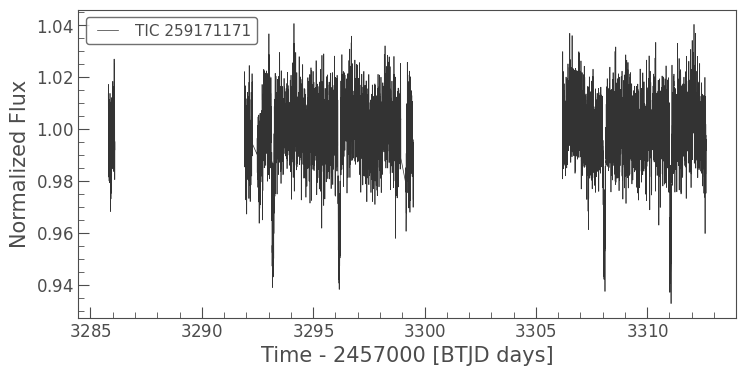

In [18]:
lc.plot()

In [ ]:
# depth += 0.02 # add extra depth after seeing folded to improve value

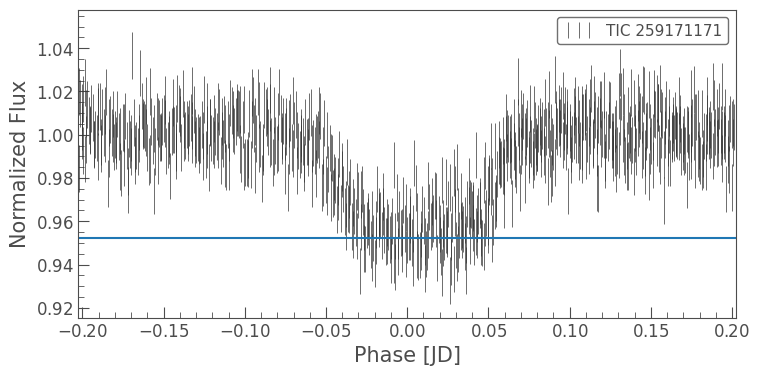

In [21]:
lc = lc.normalize()
flc = lc.fold(period = period, epoch_time = transit_time)
flc.errorbar()
plot.hlines([1 - depth], flc.time.min().value, flc.time.max().value)
plot.xlim(-duration * 2, duration * 2)
plot.show()

<Axes: xlabel='Phase [JD]', ylabel='Normalized Flux'>

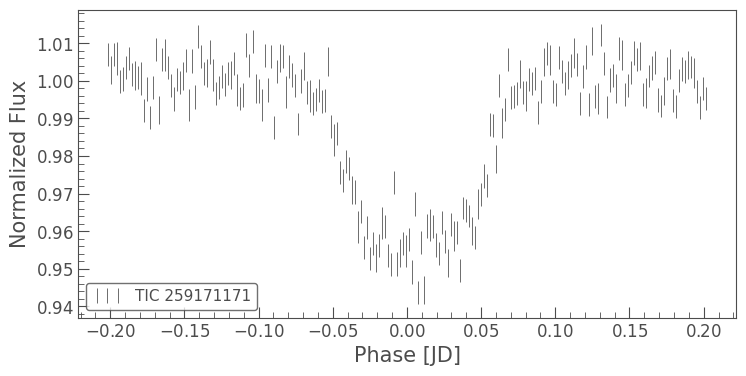

In [22]:
mask = numpy.abs(flc.time) < duration * 2
mflc = flc[mask]
blc = mflc.bin(time_bin_size = (2 * duration * 2) / 200)
blc.errorbar()

In [23]:
target = tr.target(ID = star_id, search_radius = 5, sectors = numpy.array(sectors), trilegal_fname = '')

Getting TessCut for sector 73


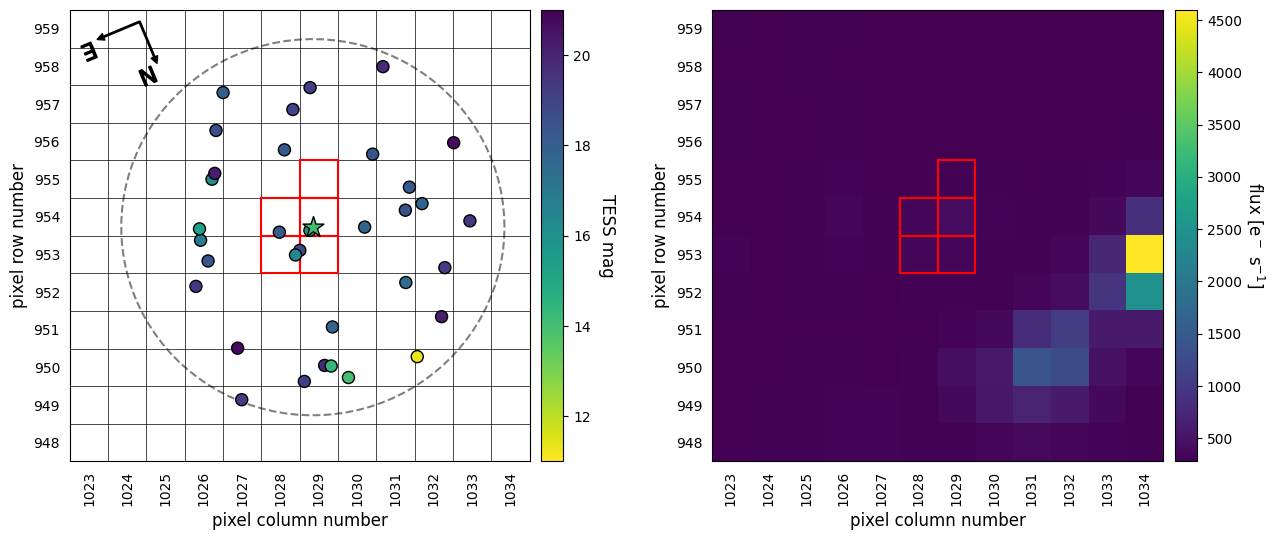

In [24]:
aps = target.get_spoc_apertures()
target.plot_field(sector = sectors[0], ap_pixels = aps[0] if aps != [] else None, ap_color = 'red')

In [25]:
target.stars

,ID,Tmag,Jmag,Hmag,Kmag,ra,dec,mass,rad,Teff,plx,sep (arcsec),PA (E of N)
0,259171171,14.0274,13.186,12.985,12.959,292.502087,70.032885,1.150000,1.465060,6117.0,0.749867,0.000,0.000
1,1884444142,15.8834,NaN,NaN,NaN,292.503814,70.033159,NaN,NaN,NaN,0.905868,2.341,65.110
2,1884444139,18.8013,NaN,NaN,NaN,292.511158,70.035361,0.670000,0.469985,4283.0,0.380613,14.275,51.365
3,259171173,16.3709,15.562,15.238,15.233,292.513626,70.035754,1.020000,0.880685,5722.0,0.457662,17.545,53.942
4,259171170,18.1952,16.301,15.763,15.307,292.516285,70.031596,0.350000,0.439157,3315.0,1.526500,18.062,104.890
5,259171174,17.7709,16.859,15.773,15.567,292.481398,70.035940,0.670000,1.101500,4264.0,0.247890,27.707,293.390
6,1884444138,18.2399,NaN,NaN,NaN,292.500588,70.020339,NaN,NaN,5285.0,0.356755,45.203,182.337
7,259171175,18.4873,16.410,16.144,15.284,292.462331,70.035979,NaN,NaN,3469.0,1.838880,50.123,282.857
8,1884444141,18.3183,NaN,NaN,NaN,292.466105,70.026174,NaN,NaN,4877.0,0.417358,50.409,241.376
9,259171172,18.2229,16.361,15.895,15.286,292.456895,70.032984,0.540000,0.393519,3679.0,1.298620,55.556,270.387


In [26]:
target.calc_depths(tdepth = depth, all_ap_pixels = aps)

In [27]:
target.stars[target.stars.tdepth > 0]

,ID,Tmag,Jmag,Hmag,Kmag,ra,dec,mass,rad,Teff,plx,sep (arcsec),PA (E of N),fluxratio,tdepth
0,259171171,14.0274,13.186,12.985,12.959,292.502087,70.032885,1.15,1.465060,6117.0,0.749867,0.000,0.000,0.746964,0.063978
1,1884444142,15.8834,NaN,NaN,NaN,292.503814,70.033159,NaN,NaN,NaN,0.905868,2.341,65.110,0.137418,0.347768
3,259171173,16.3709,15.562,15.238,15.233,292.513626,70.035754,1.02,0.880685,5722.0,0.457662,17.545,53.942,0.074729,0.639505


In [28]:
target.calc_probs(
    time = blc.time.value,                               # binned time data
    flux_0 = blc.flux.value,                             # binned flux data
    flux_err_0 = numpy.mean(blc.flux_err.value),            # standard deviation of (out-of-transit) flux data
    P_orb = period,                              # best-fit orbital period of planet candidate
    contrast_curve_file = None,        # contrast curve file to use (str)
    filt = 'TESS',                                # number of instances to simulate for each scenario (int, usually fine to leave alone)
    parallel = True,                               # whether or not to use parallel processing (bool)
    drop_scenario = ['DTP', 'DEB', 'DEBx2P', 'BTP', 'BEB', 'BEBx2P', 'NTP', 'NEB', 'NEB2xP'],                            # scenarios to ignore (e.g., "EB")
    verbose = 1,                                   # whether or not to print updates (0 or 1)
    flatpriors = False,                            # whether or not to assume flat planet priors (bool)
    exptime = exptime,                             # exposure time of TESS data (float, in days)
    molusc_file = None
)

Calculating TP scenario probabilitiey for 259171171.
Calculating EB and EBx2P scenario probabilities for 259171171.
Calculating PTP scenario probability for 259171171.
Calculating PEB and PEBx2P scenario probabilities for 259171171.
Calculating STP scenario probability for 259171171.
Calculating SEB and SEBx2P scenario probabilities for 259171171.
Calculating NTP, NEB, and NEB2xP scenario probabilities for 1884444142.
Calculating NTP, NEB, and NEB2xP scenario probabilities for 259171173.


In [29]:
target.probs

,ID,scenario,M_s,R_s,P_orb,inc,b,ecc,w,R_p,M_EB,R_EB,prob
0,259171171,TP,1.150000,1.465060,2.977393,89.267572,0.064677,0.196837,68.626785,19.977155,0.000000,0.000000,0.000000e+00
1,259171171,EB,1.150000,1.465060,2.977393,83.169415,1.216318,0.755554,251.472700,0.000000,0.319440,0.334345,1.000000e+00
2,259171171,EBx2P,1.150000,1.465060,5.954785,82.389538,1.836625,0.198281,315.369862,0.000000,1.132269,1.261282,8.442897e-27
3,259171171,PTP,1.150000,1.465060,2.977393,88.944306,0.118272,0.142618,339.695620,19.979638,0.000000,0.000000,0.000000e+00
4,259171171,PEB,1.150000,1.465060,2.977393,84.450214,1.027767,0.577761,266.178578,0.000000,0.317830,0.332986,5.355252e-10
5,259171171,PEBx2P,1.150000,1.465060,5.954785,82.102111,1.832506,0.310220,328.812670,0.000000,1.110973,1.234272,1.082444e-27
6,259171171,STP,1.124960,1.252117,2.977393,88.379785,0.182646,0.183543,153.406011,19.823199,0.000000,0.000000,0.000000e+00
7,259171171,SEB,1.129181,1.257424,2.977393,86.930665,0.435814,0.024201,321.723936,0.000000,0.424289,0.423901,6.069862e-21
8,259171171,SEBx2P,1.025325,1.116133,5.954785,84.547711,1.682805,0.231435,314.465577,0.000000,0.980635,1.050929,1.637671e-34
9,259171171,DTP,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00


In [30]:
print('FPP = ', target.FPP) # eb on this star, etc.
print('NFPP = ', target.NFPP) # nearby contamination

FPP =  1.0
NFPP =  1.8829131000622346e-35


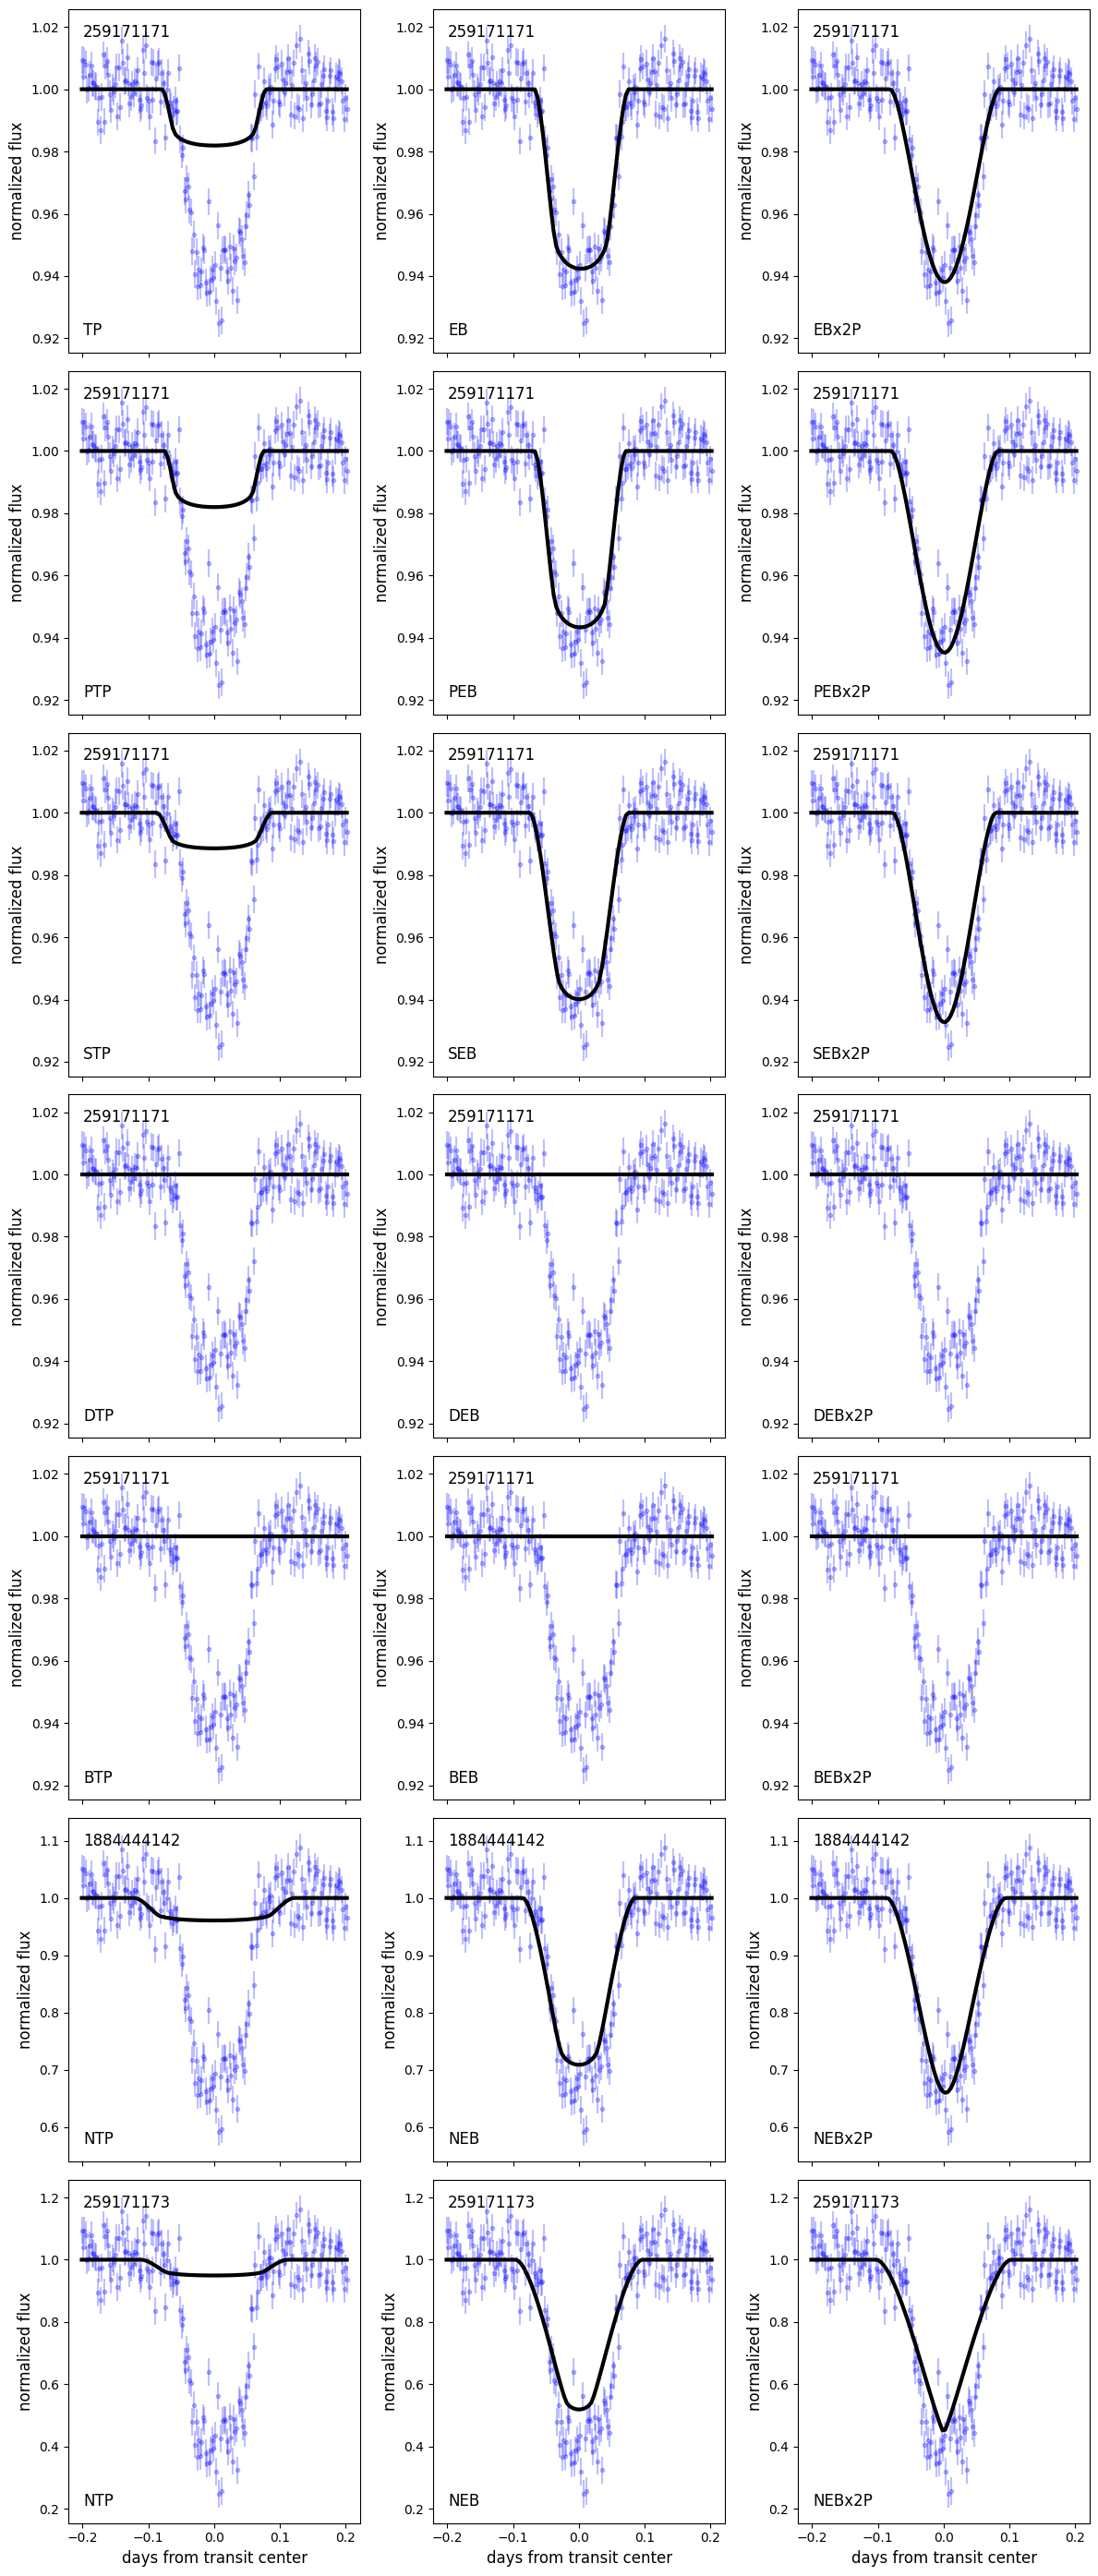

In [31]:
target.plot_fits(
    time = blc.time.value,                               # binned time data
    flux_0 = blc.flux.value,                             # binned flux data
    flux_err_0 = numpy.mean(blc.flux_err.value)
)